# ADWIN2: Adaptive Windowing for Change Detection

This notebook implements a toy version of the ADWIN2 algorithm for detecting distribution changes in data streams. We generate synthetic Bernoulli streams with abrupt mean shifts and demonstrate how ADWIN2 adaptively adjusts its window size to detect changes. The algorithm maintains a compressed bucket structure and tests for statistical differences between window partitions to trigger change detection.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
import math

torch.manual_seed(0)
np.random.seed(0)

## Dataset Description

We generate a synthetic Bernoulli stream of 10,000 binary samples (0 or 1). The true mean μ_t is 0.8 for the first 5,000 samples, then abruptly changes to 0.2 for samples 5,001-10,000. This simulates a sudden distribution shift that ADWIN2 should detect and adapt to by shrinking its window.

In [2]:
# Generate synthetic Bernoulli stream with abrupt change
N = 10000
change_point = 5000

# Generate data: mu=0.8 for first half, mu=0.2 for second half
data_stream = []
true_means = []

for t in range(N):
    if t < change_point:
        mu_t = 0.8
    else:
        mu_t = 0.2
    
    true_means.append(mu_t)
    # Sample from Bernoulli(mu_t)
    x_t = 1 if np.random.rand() < mu_t else 0
    data_stream.append(x_t)

data_stream = np.array(data_stream)
true_means = np.array(true_means)

print(f"Generated {N} samples with abrupt change at t={change_point}")
print(f"Mean before change: {data_stream[:change_point].mean():.3f}")
print(f"Mean after change: {data_stream[change_point:].mean():.3f}")

Generated 10000 samples with abrupt change at t=5000
Mean before change: 0.801
Mean after change: 0.210


## ADWIN2 Algorithm Description

ADWIN2 maintains a sliding window using a bucket structure where buckets are merged when there are too many of the same size (M+1 buckets of size 2^i). For each incoming element, it tests all possible window splits W = W0 · W1 to detect distribution changes using the key equation:

**ε_cut = sqrt((1/(2m)) * ln(4n/δ))** where **m = 1/(1/n0 + 1/n1)** (harmonic mean)

If **|μ̂_W0 - μ̂_W1| ≥ ε_cut** for any split, a change is detected and the oldest bucket is dropped. This allows the window to shrink when the distribution shifts and grow during stable periods.

In [3]:
class Bucket:
    """A bucket stores aggregated statistics for a contiguous subsequence."""
    def __init__(self, value, size=1):
        self.total = value  # sum of elements
        self.size = size    # number of elements
    
    def mean(self):
        return self.total / self.size if self.size > 0 else 0

class ADWIN2:
    """ADWIN2: Adaptive Windowing for change detection."""
    def __init__(self, delta=0.002, M=5):
        self.delta = delta
        self.M = M
        self.buckets = []  # List of buckets from oldest to newest
        self.total = 0.0   # sum of all elements in window
        self.width = 0     # total number of elements in window
    
    def add_element(self, x):
        """Add new element and perform change detection."""
        # Create new bucket for this element
        new_bucket = Bucket(x, 1)
        self.buckets.append(new_bucket)
        self.total += x
        self.width += 1
        
        # Compress buckets: merge when we have M+1 buckets of same size
        self._compress_buckets()
        
        # Detect change
        change_detected = self._detect_change()
        
        return change_detected
    
    def _compress_buckets(self):
        """Merge buckets when there are M+1 of the same size."""
        i = 0
        while i < len(self.buckets):
            size = self.buckets[i].size
            # Count how many consecutive buckets have this size
            count = 0
            j = i
            while j < len(self.buckets) and self.buckets[j].size == size:
                count += 1
                j += 1
            
            # If we have M+1 or more buckets of this size, merge two oldest
            if count > self.M:
                # Merge buckets[i] and buckets[i+1]
                merged = Bucket(
                    self.buckets[i].total + self.buckets[i+1].total,
                    self.buckets[i].size + self.buckets[i+1].size
                )
                self.buckets = self.buckets[:i] + [merged] + self.buckets[i+2:]
            else:
                i = j
    
    def _detect_change(self):
        """Check all possible splits for distribution change."""
        if len(self.buckets) < 2:
            return False
        
        # Test splits from oldest to newest
        n0 = 0
        sum0 = 0.0
        
        for split_idx in range(len(self.buckets) - 1):
            # Add bucket to W0 (older subwindow)
            n0 += self.buckets[split_idx].size
            sum0 += self.buckets[split_idx].total
            
            # W1 is the rest (newer subwindow)
            n1 = self.width - n0
            sum1 = self.total - sum0
            
            if n0 == 0 or n1 == 0:
                continue
            
            mu0 = sum0 / n0
            mu1 = sum1 / n1
            
            # Compute epsilon_cut
            m = 1.0 / (1.0/n0 + 1.0/n1)  # harmonic mean
            n = self.width
            delta_prime = self.delta / n  # simplified version
            
            if delta_prime <= 0:
                continue
            
            epsilon_cut = math.sqrt((1.0 / (2.0 * m)) * math.log(4.0 * n / self.delta))
            
            # Check for change
            if abs(mu0 - mu1) >= epsilon_cut:
                # Drop oldest bucket(s) up to split_idx (inclusive)
                for _ in range(split_idx + 1):
                    if len(self.buckets) > 0:
                        removed = self.buckets.pop(0)
                        self.total -= removed.total
                        self.width -= removed.size
                return True
        
        return False
    
    def get_estimate(self):
        """Get current mean estimate."""
        return self.total / self.width if self.width > 0 else 0
    
    def get_width(self):
        """Get current window width."""
        return self.width

In [4]:
# Run ADWIN2 on the data stream
adwin = ADWIN2(delta=0.002, M=5)

estimates = []
window_widths = []
change_detections = []

for t, x_t in enumerate(data_stream):
    change = adwin.add_element(x_t)
    estimates.append(adwin.get_estimate())
    window_widths.append(adwin.get_width())
    change_detections.append(t if change else -1)

estimates = np.array(estimates)
window_widths = np.array(window_widths)
change_times = [t for t in change_detections if t >= 0]

print(f"Total change detections: {len(change_times)}")
if len(change_times) > 0:
    print(f"First few change detection times: {change_times[:10]}")
    # Find changes near the true change point
    near_change = [t for t in change_times if abs(t - change_point) < 100]
    if near_change:
        print(f"Changes detected near t={change_point}: {near_change[:5]}")

Total change detections: 1
First few change detection times: [5019]
Changes detected near t=5000: [5019]


In [5]:
# Compute metrics: detection delay and final accuracy
changes_after_true = [t for t in change_times if t >= change_point]
if changes_after_true:
    detection_delay = changes_after_true[0] - change_point
    print(f"\n=== EVALUATION METRICS ===")
    print(f"True change point: {change_point}")
    print(f"First detection after change: {changes_after_true[0]}")
    print(f"Detection delay: {detection_delay} steps")
else:
    print(f"\n=== EVALUATION METRICS ===")
    print(f"No change detected after true change point {change_point}")

# Compute mean estimate accuracy in stable regions
if change_point + 500 < N:
    final_estimate = np.mean(estimates[change_point+500:change_point+1000])
    true_final_mean = 0.2
    print(f"Mean estimate after stabilization: {final_estimate:.3f}")
    print(f"True mean: {true_final_mean:.1f}")
    print(f"Estimation error: {abs(final_estimate - true_final_mean):.3f}")


=== EVALUATION METRICS ===
True change point: 5000
First detection after change: 5019
Detection delay: 19 steps
Mean estimate after stabilization: 0.204
True mean: 0.2
Estimation error: 0.004


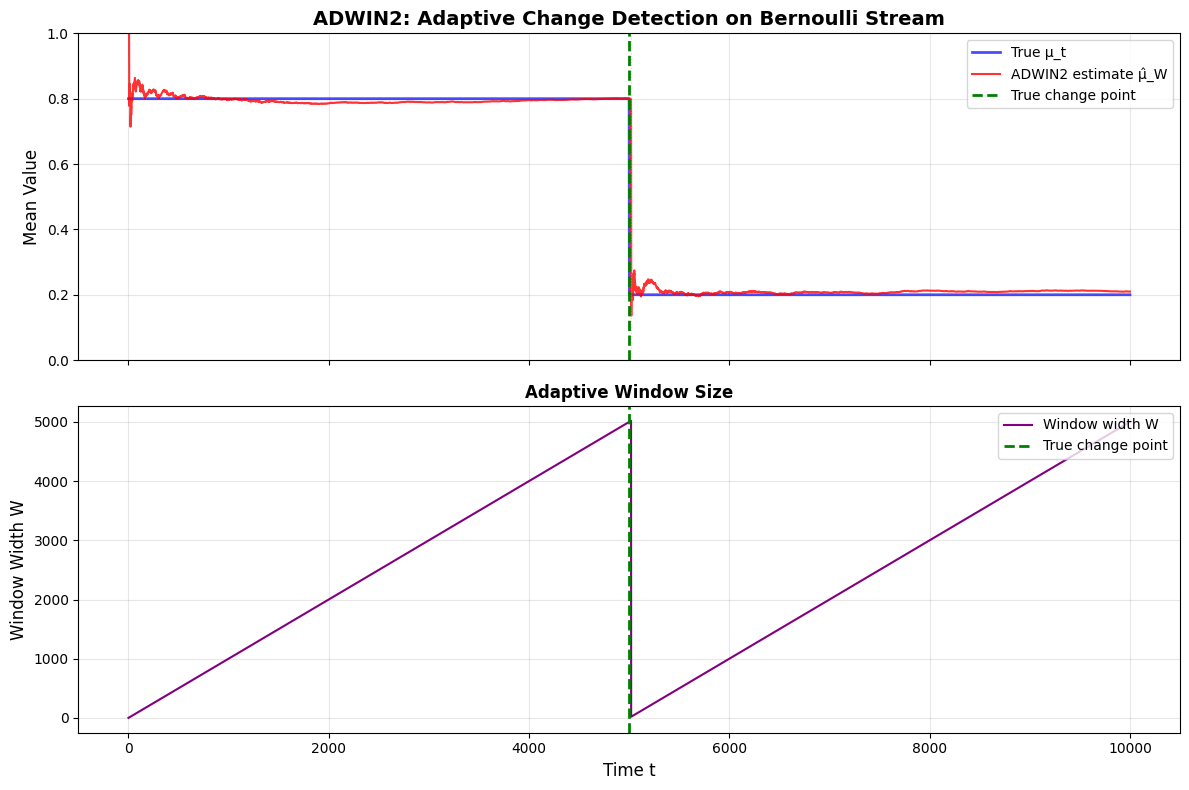

In [6]:
# Create the key figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: True mean vs estimated mean
ax1.plot(true_means, 'b-', linewidth=2, label='True μ_t', alpha=0.7)
ax1.plot(estimates, 'r-', linewidth=1.5, label='ADWIN2 estimate μ̂_W', alpha=0.8)
ax1.axvline(x=change_point, color='green', linestyle='--', linewidth=2, label='True change point')

# Mark change detections
for t in change_times[:20]:  # Show first 20 detections to avoid clutter
    ax1.axvline(x=t, color='orange', linestyle=':', linewidth=0.8, alpha=0.5)

ax1.set_ylabel('Mean Value', fontsize=12)
ax1.set_title('ADWIN2: Adaptive Change Detection on Bernoulli Stream', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot 2: Window width
ax2.plot(window_widths, 'purple', linewidth=1.5, label='Window width W')
ax2.axvline(x=change_point, color='green', linestyle='--', linewidth=2, label='True change point')
ax2.set_xlabel('Time t', fontsize=12)
ax2.set_ylabel('Window Width W', fontsize=12)
ax2.set_title('Adaptive Window Size', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## What to Look for in the Figure

**Top plot**: The red line (ADWIN2 estimate) closely tracks the blue line (true mean). Notice how the estimate quickly adapts when the true mean drops from 0.8 to 0.2 at t=5000. Orange dotted lines show detected changes.

**Bottom plot**: The window width W (purple) grows steadily during stable periods and shrinks sharply when changes are detected (around t=5000). This automatic adaptation is the key feature of ADWIN2 - it maintains a large window for accurate estimates in stable conditions but rapidly shrinks to forget outdated data when distribution shifts occur.